# Estimate cascade rates: serial vs MPI on sample data

This notebook mirrors the workflow in `ex_cascade.ipynb`, but after computing the tutorial's serial result it launches a real MPI helper script on the same sample dataset and compares the resulting structure functions and cascade-rate estimates side by side.

In [1]:
from pathlib import Path
import subprocess
import sys
import warnings

import fluidsf
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pooch
from scipy.stats import bootstrap

warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve()
while not (ROOT / "examples" / "python_scripts").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate the repository root.")
    ROOT = ROOT.parent
OUT = ROOT / "examples" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

BOOTSTRAP_KWARGS = {
    "confidence_level": 0.5,
    "axis": 0,
    "random_state": 0,
}


def max_abs_diff_ignore_nonfinite(serial_values, mpi_values):
    serial_values = np.asarray(serial_values)
    mpi_values = np.asarray(mpi_values)
    valid = np.isfinite(serial_values) & np.isfinite(mpi_values)
    if not np.any(valid):
        return 0.0
    return float(np.max(np.abs(serial_values[valid] - mpi_values[valid])))


def bootstrap_sf_statistics(sfs_list):
    sf_asf_x = np.asarray([sf["SF_advection_velocity_x"] for sf in sfs_list])
    sf_asf_y = np.asarray([sf["SF_advection_velocity_y"] for sf in sfs_list])
    sf_lll_x = np.asarray([sf["SF_LLL_x"] for sf in sfs_list])
    sf_lll_y = np.asarray([sf["SF_LLL_y"] for sf in sfs_list])

    boot_asf_x = bootstrap((sf_asf_x,), np.mean, **BOOTSTRAP_KWARGS)
    boot_asf_y = bootstrap((sf_asf_y,), np.mean, **BOOTSTRAP_KWARGS)
    boot_lll_x = bootstrap((sf_lll_x,), np.mean, **BOOTSTRAP_KWARGS)
    boot_lll_y = bootstrap((sf_lll_y,), np.mean, **BOOTSTRAP_KWARGS)

    return {
        "boot_ASF_x_mean": boot_asf_x.bootstrap_distribution.mean(axis=1),
        "boot_ASF_y_mean": boot_asf_y.bootstrap_distribution.mean(axis=1),
        "boot_LLL_x_mean": boot_lll_x.bootstrap_distribution.mean(axis=1),
        "boot_LLL_y_mean": boot_lll_y.bootstrap_distribution.mean(axis=1),
        "boot_ASF_x_conf_low": boot_asf_x.confidence_interval[0],
        "boot_ASF_x_conf_high": boot_asf_x.confidence_interval[1],
        "boot_ASF_y_conf_low": boot_asf_y.confidence_interval[0],
        "boot_ASF_y_conf_high": boot_asf_y.confidence_interval[1],
        "boot_LLL_x_conf_low": boot_lll_x.confidence_interval[0],
        "boot_LLL_x_conf_high": boot_lll_x.confidence_interval[1],
        "boot_LLL_y_conf_low": boot_lll_y.confidence_interval[0],
        "boot_LLL_y_conf_high": boot_lll_y.confidence_interval[1],
    }


def estimate_cascade_rates(stats, x_diffs, y_diffs):
    return {
        "epsilon_LLL_x_mean": -2 * stats["boot_LLL_x_mean"] / (3 * x_diffs),
        "epsilon_LLL_y_mean": -2 * stats["boot_LLL_y_mean"] / (3 * y_diffs),
        "epsilon_ASF_x_mean": -stats["boot_ASF_x_mean"] / 2,
        "epsilon_ASF_y_mean": -stats["boot_ASF_y_mean"] / 2,
        "epsilon_LLL_x_conf_low": -2 * stats["boot_LLL_x_conf_low"] / (3 * x_diffs),
        "epsilon_LLL_x_conf_high": -2 * stats["boot_LLL_x_conf_high"] / (3 * x_diffs),
        "epsilon_LLL_y_conf_low": -2 * stats["boot_LLL_y_conf_low"] / (3 * y_diffs),
        "epsilon_LLL_y_conf_high": -2 * stats["boot_LLL_y_conf_high"] / (3 * y_diffs),
        "epsilon_ASF_x_conf_low": -stats["boot_ASF_x_conf_low"] / 2,
        "epsilon_ASF_x_conf_high": -stats["boot_ASF_x_conf_high"] / 2,
        "epsilon_ASF_y_conf_low": -stats["boot_ASF_y_conf_low"] / 2,
        "epsilon_ASF_y_conf_high": -stats["boot_ASF_y_conf_high"] / 2,
    }

## Load the same sample dataset as the cascade tutorial

We use the same 2D quasi-geostrophic sample data as `ex_cascade.ipynb`, including the same top-layer visualization before computing the structure functions.

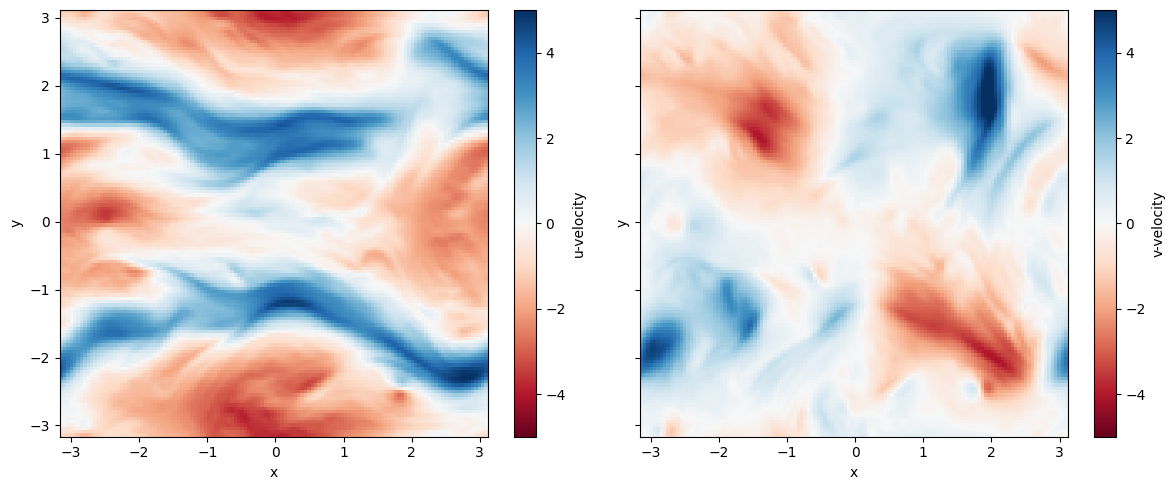

In [2]:
file_path = pooch.retrieve(
    url="https://zenodo.org/records/15278227/files/2layer_128.jld2",
    known_hash="a04abc602ca3bbc4ff9a868a96848b6815a17f697202fb12e3ff40762de92ec6",
)

f = h5py.File(file_path, "r")
grid = f["grid"]
snapshots = f["snapshots"]

x = grid["x"][()]
y = grid["y"][()]
u = snapshots["u"]
v = snapshots["v"]
snapshot_keys = sorted(u.keys(), key=int)

fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(12, 5))
p1 = ax1.pcolormesh(x, y, u[snapshot_keys[-1]][0], cmap="RdBu", vmin=-5, vmax=5)
p2 = ax2.pcolormesh(x, y, v[snapshot_keys[-1]][0], cmap="RdBu", vmin=-5, vmax=5)
fig.colorbar(p1, label="u-velocity")
fig.colorbar(p2, label="v-velocity")
ax1.set_xlabel("x")
ax2.set_xlabel("x")
ax1.set_ylabel("y")
ax2.set_ylabel("y")
plt.tight_layout()

## Compute the serial cascade estimate

This cell follows the tutorial workflow directly: calculate the two velocity-based structure functions for every snapshot, bootstrap their means, and convert those means into inverse energy cascade estimates.

For the quasi-geostrophic case shown here,

$\epsilon = -2 SF^3_v / 3\mathbf{r}$

$\epsilon = - ASF_v / 2$

In [3]:
serial_sfs_list = [
    fluidsf.generate_structure_functions_2d(
        u[snapshot][0],
        v[snapshot][0],
        x,
        y,
        sf_type=["ASF_V", "LLL"],
        boundary="periodic-all",
    )
    for snapshot in snapshot_keys
]

x_diffs = serial_sfs_list[0]["x-diffs"]
y_diffs = serial_sfs_list[0]["y-diffs"]
serial_stats = bootstrap_sf_statistics(serial_sfs_list)
serial_cascade = estimate_cascade_rates(serial_stats, x_diffs, y_diffs)
comparison_keys = sorted({*serial_stats.keys(), *serial_cascade.keys()})

## Launch the MPI version of the same workflow

The notebook kernel itself is still a normal single-process Python session, so the real MPI calculation is launched in a subprocess with `mpirun`. The helper script writes the rank-0 arrays to disk so they can be loaded back into notebook variables.

The zero-separation bin produces non-finite values for some reported confidence intervals and for the `SF_LLL`-based cascade estimate, because that formula divides by separation distance. The comparison below ignores those non-finite bins and compares the finite entries only.

In [4]:
cmd = [
    "mpirun",
    "-launcher",
    "fork",
    "-n",
    "4",
    sys.executable,
    str(ROOT / "examples/python_scripts/ex_cascade_serial_vs_mpi_sample_data.py"),
    "--output-dir",
    str(OUT),
    "--mpi-only",
]
completed = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True, check=True)

summary_lines = [
    line
    for line in completed.stdout.splitlines()
    if line.startswith("MPI ranks participating:")
    or line.startswith("Saved MPI-only outputs to")
]
print("\n".join(summary_lines))

mpi_npz = np.load(OUT / "ex_cascade_serial_vs_mpi_sample_data.npz")
mpi_stats = {key: mpi_npz[f"mpi_{key}"] for key in serial_stats}
mpi_cascade = {key: mpi_npz[f"mpi_{key}"] for key in serial_cascade}

for key in comparison_keys:
    mpi_values = mpi_stats.get(key, mpi_cascade.get(key))
    serial_values = serial_stats.get(key, serial_cascade.get(key))
    diff = max_abs_diff_ignore_nonfinite(serial_values, mpi_values)
    print(f"{key}: max abs diff = {diff:.3e}")

MPI ranks participating: [0, 1, 2, 3]
Saved outputs to /Users/victorzendejaslopez/Documents/fluidsf/examples/outputs
Largest diff = nan
boot_ASF_x_conf_high: max abs diff = nan
boot_ASF_x_conf_low: max abs diff = nan
boot_ASF_x_mean: max abs diff = 2.220e-16
boot_ASF_y_conf_high: max abs diff = nan
boot_ASF_y_conf_low: max abs diff = nan
boot_ASF_y_mean: max abs diff = 1.388e-16
boot_LLL_x_conf_high: max abs diff = nan
boot_LLL_x_conf_low: max abs diff = nan
boot_LLL_x_mean: max abs diff = 2.220e-16
boot_LLL_y_conf_high: max abs diff = nan
boot_LLL_y_conf_low: max abs diff = nan
boot_LLL_y_mean: max abs diff = 1.665e-16
epsilon_ASF_x_conf_high: max abs diff = nan
epsilon_ASF_x_conf_low: max abs diff = nan
epsilon_ASF_x_mean: max abs diff = 1.110e-16
epsilon_ASF_y_conf_high: max abs diff = nan
epsilon_ASF_y_conf_low: max abs diff = nan
epsilon_ASF_y_mean: max abs diff = 6.939e-17
epsilon_LLL_x_conf_high: max abs diff = nan
epsilon_LLL_x_conf_low: max abs diff = nan
epsilon_LLL_x_mean: m

## Plot the serial and MPI cascade estimates together

The serial curves use the same layout as the tutorial. The MPI curves are overlaid with different line styles so agreement can be inspected visually.

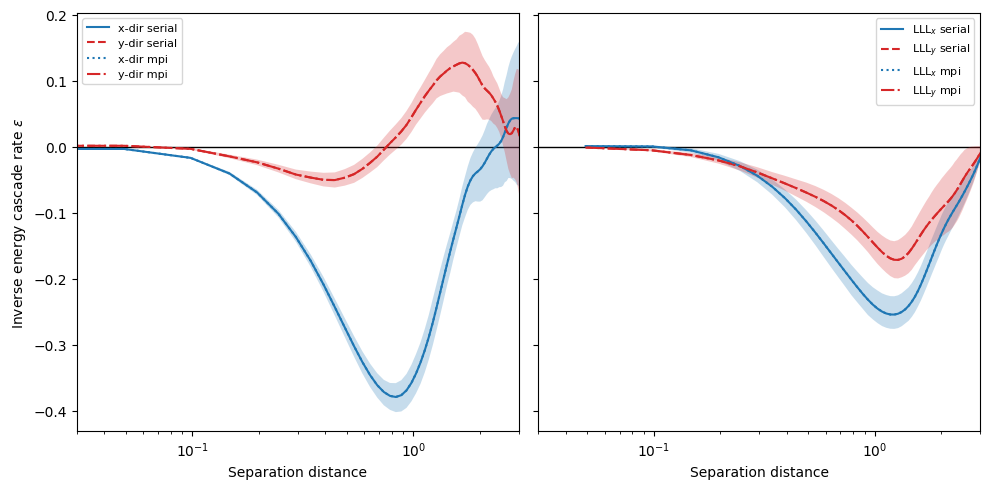

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax2.semilogx(x_diffs, serial_cascade["epsilon_LLL_x_mean"], label=r"LLL$_x$ serial", color="tab:blue")
ax2.semilogx(
    y_diffs,
    serial_cascade["epsilon_LLL_y_mean"],
    label=r"LLL$_y$ serial",
    color="tab:red",
    linestyle="dashed",
)
ax2.semilogx(x_diffs, mpi_cascade["epsilon_LLL_x_mean"], label=r"LLL$_x$ mpi", color="tab:blue", linestyle=":")
ax2.semilogx(y_diffs, mpi_cascade["epsilon_LLL_y_mean"], label=r"LLL$_y$ mpi", color="tab:red", linestyle="-.")

ax1.semilogx(x_diffs, serial_cascade["epsilon_ASF_x_mean"], label=r"x-dir serial", color="tab:blue")
ax1.semilogx(
    y_diffs,
    serial_cascade["epsilon_ASF_y_mean"],
    label=r"y-dir serial",
    color="tab:red",
    linestyle="dashed",
)
ax1.semilogx(x_diffs, mpi_cascade["epsilon_ASF_x_mean"], label=r"x-dir mpi", color="tab:blue", linestyle=":")
ax1.semilogx(y_diffs, mpi_cascade["epsilon_ASF_y_mean"], label=r"y-dir mpi", color="tab:red", linestyle="-.")

ax1.fill_between(
    x_diffs,
    serial_cascade["epsilon_ASF_x_conf_low"],
    serial_cascade["epsilon_ASF_x_conf_high"],
    color="tab:blue",
    alpha=0.25,
    edgecolor=None,
)
ax1.fill_between(
    y_diffs,
    serial_cascade["epsilon_ASF_y_conf_low"],
    serial_cascade["epsilon_ASF_y_conf_high"],
    color="tab:red",
    alpha=0.25,
    edgecolor=None,
)
ax2.fill_between(
    x_diffs,
    serial_cascade["epsilon_LLL_x_conf_low"],
    serial_cascade["epsilon_LLL_x_conf_high"],
    color="tab:blue",
    alpha=0.25,
    edgecolor=None,
)
ax2.fill_between(
    y_diffs,
    serial_cascade["epsilon_LLL_y_conf_low"],
    serial_cascade["epsilon_LLL_y_conf_high"],
    color="tab:red",
    alpha=0.25,
    edgecolor=None,
)

ax1.set_ylabel(r"Inverse energy cascade rate $\epsilon$")
ax1.set_xlabel(r"Separation distance")
ax2.set_xlabel(r"Separation distance")
ax1.set_xlim(3e-2, 3e0)
ax2.set_xlim(3e-2, 3e0)
ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
ax1.hlines(0, 3e-2, 3e0, color="k", lw=1, zorder=0)
ax2.hlines(0, 3e-2, 3e0, color="k", lw=1, zorder=0)
plt.tight_layout()